In [1]:
from typing import TypedDict ,List ,Union
from langchain_core.messages import HumanMessage ,AIMessage
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph ,START ,END
from dotenv import load_dotenv
from typing import Annotated , Sequence ,TypedDict
from langchain_core.messages import BaseMessage ,ToolMessage ,SystemMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph  ,END ,START
from langgraph.prebuilt import ToolNode
from langchain.chat_models import init_chat_model


In [2]:
import os
import pandas as pd
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.llms import Ollama
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.output_parsers import StrOutputParser

from typing import Annotated , Sequence ,TypedDict
from langchain_core.messages import BaseMessage ,ToolMessage ,SystemMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph  ,END ,START
from langgraph.prebuilt import ToolNode
from langchain.chat_models import init_chat_model


import operator
from typing import TypedDict, Sequence, Annotated

# Import necessary components from langchain and langgraph
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
# Assuming init_chat_model is a placeholder, using ChatOllama as an example
from langchain_community.chat_models import ChatOllama
from langchain_core.tools import tool # Correct import for @tool decorator
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [3]:
llm = init_chat_model(
    model="llama3.1:latest ",#"phi3.5:latest",#phi3.5",  # The name of the model in Ollama #'deepseek-r1:1.5b',# llama3.2:latest phi3.5:latest 
    model_provider="ollama",  # Explicitly state the provider
    temperature=0.7,  # Optional: control creativity
    # base_url="http://localhost:11434" # Optional: If your Ollama is on a different host/port
)

In [4]:
PDF_PATH = 'The styrene production.pdf'#'Production_of_Cumene_from_Benzene_Propylene.pdf'#"eg_asp.pdf"#"IPA1.pdf"
LLM_MODEL ='llama3.2:3b'#'deepseek-r1:1.5b'#"llama3.1:latest" #"llama3.2:3b"#"llama3.2:latest",#"phi3.5:latest",# "llama3.1:latest" #
EMBEDDING_MODEL ="mxbai-embed-large"# "snowflake-arctic-embed:33m"#

In [5]:
def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating/updating a ChromaDB vector store,
    and initializing the LangChain components.

    This modified version removes the 'add' and 'remove/replace' options
    and defaults to using the existing vector store if it's found.

    Args:
        pdf_path (str): The file path to the PDF document.

    Returns:
        The configured RAG chain.
    """
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"

    embeddings = OllamaEmbeddings(model="mxbai-embed-large")  # Use a specific model for embeddings
    vector_store = None  # Initialize vector_store variable

    # Check if the vector store directory exists and is not empty
    if os.path.exists(persist_directory) and os.listdir(persist_directory):
        print(f"A RAG vector store for '{db_name}' already exists. Continuing with the existing store...")
        # Load the existing vector store without making changes
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )
    else:
        print(f"Creating a new ChromaDB vector store for '{db_name}' at '{persist_directory}'...")
        loader = PyPDFLoader(pdf_path)
        documents = loader.load()
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
        docs = text_splitter.split_documents(documents)

        if not docs:
            print("Error: The PDF file is empty or could not be processed.")
            return None

        vector_store = Chroma.from_documents(
            documents=docs,
            embedding=embeddings,
            persist_directory=persist_directory
        )
        print("New vector store created successfully.")

    # Check if a vector store was successfully created/loaded
    if not vector_store:
        return None

    # RAG Chain setup logic, common to both paths
    retriever = vector_store.as_retriever(search_kwargs={"k": 5})
    llm = ChatOllama(model="llama3.2:3b")  # Use a specific chat model

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 

    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
            {"context": retriever | format_docs, "question": RunnablePassthrough()}
            | prompt
            | llm
            | StrOutputParser()
    )

    return rag_chain




In [6]:
# Step 1: Feed Preparation
# - The feed is preheated to 95°C at a constant pressure of 1.01325 bar.

# Step 2: Pressurization
# - The preheated feed is sent to a pump to increase its pressure from 1.01325 bar to 13 bar.

# Step 3: Conversion Reactor
# - The pressurized feed enters a conversion reactor where ethyl benzene (styrene) is produced with a 70% conversion rate based on benzene.
# - The product stream contains ethyl benzene, unreacted ethylene, and benzene.

# Step 4: Cooling
# - The product stream from the conversion reactor is directed to a cooler that reduces its temperature to 150°C.

# Step 5: Distillation Column
# - After cooling, the stream proceeds to a first distillation column.
# - The purified ethyl benzene (styrene) acts as the bottom product.
# - The distillate contains unreacted ethylene and benzene.

# Note: Styrene is not directly produced in this process; instead, it's formed during the conversion of benzene into ethyl benzene.

In [7]:

rag_chain = setup_rag_chain(PDF_PATH)
# response = rag_chain.invoke('explain the styrene production process in steps')
# print('response',response)
response = rag_chain.invoke('what is the composition of the feed stream . its temperature , pressure , flowrate and all the chemical involved in the process including input , output , side prodct , catalyst and innert chemicals')
print('response',response)

C:\Users\rkuma\AppData\Local\Temp\ipykernel_10620\1220533310.py:18: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaEmbeddings``.
  embeddings = OllamaEmbeddings(model="mxbai-embed-large")  # Use a specific model for embeddings


A RAG vector store for 'The styrene production' already exists. Continuing with the existing store...


C:\Users\rkuma\AppData\Local\Temp\ipykernel_10620\1220533310.py:53: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  llm = ChatOllama(model="llama3.2:3b")  # Use a specific chat model


response Based on the provided context, here is the composition of the feed stream:

- Temperature: 95°C
- Pressure: 1.01325 bar (increased to 13 bar after passing through a pump)
- Flowrate: 
  - Molar flow rate: 9.419034 kmol/h
  - Mass flow rate: 500 kg/h

As for the chemical involved in the process, including inputs, outputs, side products, catalyst, and inner chemicals:

Inputs:
- Benzene (C6H6)
- Ethylene (C2H4)

Outputs:
- Ethyl benzene (C6H5CH3)
- Unreacted ethylene (C2H4)
- Unreacted benzene (C6H6)

Side products and intermediates are not explicitly mentioned in the provided context.

There is no mention of a catalyst being used in the process, so it can be inferred that the reaction proceeds without a catalyst.

Please note that this information only includes what was directly stated in the context. If there's any additional relevant information available elsewhere, it might provide further details about the composition or other aspects of the feed stream.


In [25]:
inlet_data_test=rag_chain.invoke('what is the inlet stream temperature , pressure and composition . list all the chemicals involved in the process and the flowrate of the stream')
print(inlet_data_test)

Based on the provided context, I can answer the question about the inlet stream temperature, pressure, composition, chemicals involved in the process, and flowrate of the stream.

Inlet Stream:

* Temperature: 95°C
* Pressure: 1.01325 bar
* Molar Composition:
	+ Benzene: 0.5 mol
	+ Ethylene: 0.5 mol

Chemicals Involved in the Process:

* Benzene (C6H6)
* Ethylene (C2H4)

Flowrate of the Stream:

* Molar Flow Rate: 9.419034 kmol/h
* Mass Flow Rate: 500 kg/h


In [ ]:


inlet_data_test=rag_chain.invoke('what is the inlet stream temperature , pressure and composition . list all the chemicals involved in the process and the flowrate of the stream.what is the inlet temperature of the feed, condition if the inlet temperature is not specified consider it as 25C, if the inlet pressure is not specified consider it as 1 bar pressure)
print(inlet_data_test)

In [27]:
inlet_data_test

'Based on the provided context, I can answer the question about the inlet stream temperature, pressure, composition, chemicals involved in the process, and flowrate of the stream.\n\nInlet Stream:\n\n* Temperature: 95°C\n* Pressure: 1.01325 bar\n* Molar Composition:\n\t+ Benzene: 0.5 mol\n\t+ Ethylene: 0.5 mol\n\nChemicals Involved in the Process:\n\n* Benzene (C6H6)\n* Ethylene (C2H4)\n\nFlowrate of the Stream:\n\n* Molar Flow Rate: 9.419034 kmol/h\n* Mass Flow Rate: 500 kg/h'

In [9]:
inlet_temp= rag_chain.invoke('what is the inlet temperature of the feed')
inlet_pressure= rag_chain.invoke('what is the inlet pressure of the feed')
feed= rag_chain.invoke('what is the components in the feed , list all the chemicals ')
chem_list= rag_chain.invoke('list all the chemical involved in the process including input , output , side products , catalyst and innert chemicals and other')
inlet_comp= rag_chain.invoke(f'what is the composition of chmicals in feed : {feed} ')
inlet_flow=rag_chain.invoke('what is the flowrate of the inlet stream')

In [10]:
inlet_pressure= rag_chain.invoke('what is the pressure of the feed')
print(inlet_pressure)

To calculate the pressure of the feed after it has been pumped up to 13 bar, we can directly read it from the context:

The initial pressure of the feed is 1.01325 bar, and it is increased to 13 bar by a pump.

So, the answer is: 13 bar


In [11]:
inlet_temp2= rag_chain.invoke('what is the inlet temperature of the feed, condition if the inlet temperature is not specified consider it as 25C')
print(inlet_temp2)

To calculate the inlet temperature of the feed, we can use the given information that the initial preheated temperature is 95°C.

Assuming a constant pressure of 1.01325 bar, we can use the ideal gas law to relate the temperature and volume of the feed. However, since the problem doesn't provide information on the volume flow rate or density of the feed, we cannot directly calculate the inlet temperature using this method.

 Nevertheless, since the feed is initially preheated to 95°C, this can be considered as the inlet temperature for our purposes.


In [12]:
print(inlet_temp)

To find the inlet temperature of the feed, we need to consider the initial preheating of the feed. The context states that the feed is initially preheated to 95∘C. Therefore, the inlet temperature of the feed is 95∘C.


In [13]:
print(inlet_pressure)

To calculate the pressure of the feed after it has been pumped up to 13 bar, we can directly read it from the context:

The initial pressure of the feed is 1.01325 bar, and it is increased to 13 bar by a pump.

So, the answer is: 13 bar


In [14]:
print(feed)

Based on the provided context, I can list some of the components in the feed. The molar composition of the inlet stream is given as 0.5 for Benzene (C6H6) and 0.5 for Ethylene (C2H4). This implies that the feed contains:

1. Benzene (C6H6)
2. Ethylene (C2H4)

Note that there are no other components mentioned in the provided context as being present in the feed.

Please note that I couldn't identify any chemical compounds with a name starting with "ethyl" since the product ethyl benzene is mentioned later in the process, not as an initial component of the feed.


In [15]:
print(chem_list)

Based on the provided context, here is a list of chemicals involved in the styrene production process:

**Input:**

1. Benzene (C6H6)
2. Ethylene (C2H4)

**Output:**

1. Ethyl benzene ((C6H5)2CH)
2. Unreacted ethylene (C2H4)
3. Unreacted benzene (C6H6)

**Side products:**

 None mentioned in the context.

**Catalyst:**

 None mentioned in the context. However, it is implied that a catalyst might be present to facilitate the conversion reaction, but its specific type and composition are not specified.

**Inner chemicals:**

1. Benzene-homogeneous reaction intermediate (not explicitly stated)
2. Ethylene-homogeneous reaction intermediate (not explicitly stated)

Please note that the context does not provide detailed information about the inner chemical species involved in the reaction mechanism.


In [16]:
print(inlet_comp)

Based on the provided context, the composition of chemicals in the feed is:

1. Benzene (C6H6)
2. Ethylene (C2H4)

These are the only two components mentioned as being present in the feed. There are no other components listed.


In [17]:
print(inlet_flow)

I don't know the flow rate of the inlet stream. The question asks for the flow rate, but the provided context only mentions the mass flow rate of 500 kg/h, which is a different quantity from flow rate.


In [18]:
inlet_data=inlet_temp2+inlet_pressure+feed+chem_list+inlet_comp+inlet_flow
print(inlet_data)

To calculate the inlet temperature of the feed, we can use the given information that the initial preheated temperature is 95°C.

Assuming a constant pressure of 1.01325 bar, we can use the ideal gas law to relate the temperature and volume of the feed. However, since the problem doesn't provide information on the volume flow rate or density of the feed, we cannot directly calculate the inlet temperature using this method.

 Nevertheless, since the feed is initially preheated to 95°C, this can be considered as the inlet temperature for our purposes.To calculate the pressure of the feed after it has been pumped up to 13 bar, we can directly read it from the context:

The initial pressure of the feed is 1.01325 bar, and it is increased to 13 bar by a pump.

So, the answer is: 13 barBased on the provided context, I can list some of the components in the feed. The molar composition of the inlet stream is given as 0.5 for Benzene (C6H6) and 0.5 for Ethylene (C2H4). This implies that the fee

In [7]:

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

# Define a simple tool function
@tool
def add(a: int, b: int) -> int:
    """This is an addition function that adds two integers."""
    return a + b

def stream(name: str, temperature: float, pressure: float, chemicals_list: list, chemical_fraction: dict, flow: float):
    """Helper function to define the stream.
    name = name of the stream
    temperature = temperature of the stream in °C
    pressure = pressure of the stream in bar
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals
    flow = flowrate of the stream mole flow
    """
    mole_frac = {}
    total_moles = sum(chemical_fraction.values()) if not flow else flow

    for chem in chemicals_list:
        if chem in chemical_fraction:
            mole_frac[chem] = chemical_fraction[chem] / total_moles if total_moles > 0 else 0
        else:
            mole_frac[chem] = 0

    stream_dict = {
        'Name': name,
        'Temperature (°C)': temperature,
        'Pressure (bar)': pressure,
        'Molar Flowrate (mol/s)': flow,
        'Mole Fraction': mole_frac,
        'Total Moles': chemical_fraction
    }
    print('stream_data',stream_dict)
    return stream_dict

# List of tools available to the LLM
tools = [stream]


llm=init_chat_model(model='llama3.2',model_provider="ollama",  # Explicitly state the provider
    temperature=0.7,).bind_tools(tools)

def model_call(state: AgentState) -> AgentState:
    """
    Invokes the language model with the current messages and returns its response.
    """
    system_prompt = SystemMessage(content='You are my AI assistance, please answer my query.')
    # Concatenate the system prompt with the current messages
    response = llm.invoke([system_prompt] + state['messages'])
    return {'messages': [response]}

# Define the conditional edge logic
def should_continue(state: AgentState) -> str:
    """
    Determines whether to continue to tools or end the conversation.
    If the last message contains tool calls, continue to tools; otherwise, end.
    """
    message = state['messages']
    last_message = message[-1]
    if not last_message.tool_calls:
        return 'end'
    else:
        return 'continue'

# Build the LangGraph
graph = StateGraph(AgentState)

# Add nodes to the graph
graph.add_node('our_agent', model_call) # Node for LLM interaction
tool_node = ToolNode(tools=tools) # Node for tool execution
graph.add_node('tools', tool_node) # Node for tool execution

# Define edges
graph.add_edge(START, 'our_agent') # Start the graph by calling our agent

# Conditional edge from 'our_agent' based on 'should_continue' logic
graph.add_conditional_edges(
    'our_agent',
    should_continue,
    {
        'continue': 'tools', # If tool calls are present, go to 'tools' node
        'end': END           # If no tool calls, end the graph
    },
)

graph.add_edge('tools', 'our_agent') # After tool execution, go back to 'our_agent'

# Compile the graph to create the runnable application
app = graph.compile()

# Function to print the stream of messages
def print_stream(stream):
    """
    Iterates through the stream of states and prints the last message in each state.
    """
    for s in stream:
        # Corrected typo: 'messsages' -> 'messages'
        message = s['messages'][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

# Example input for the graph
# Corrected message format: use HumanMessage object
inputs = {'messages': [HumanMessage(content="Add 3 and 4")]}

# Run the application and print the stream
print_stream(app.stream(inputs, stream_mode='values'))


================================ Human Message =================================

Add 3 and 4


ResponseError: model "llama3.2" not found, try pulling it first (status code: 404)

In [28]:
import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage, AIMessage
from langchain_community.chat_models import ChatOllama
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
import json

# Define the state for the agent
class AgentState(TypedDict):
    """
    State for the agent to track messages and other data.
    """
    messages: Annotated[Sequence[BaseMessage], operator.add]

# Define the stream tool
@tool
def stream(name: str, temperature: float, pressure: float, chemicals_list: list, chemical_fraction: dict, flow: float = None):
    """
    Defines a chemical stream with specific properties.
    Use this tool to simulate a chemical process stream.
    name: The name of the stream (e.g., 'Feed').
    temperature: The temperature of the stream in degrees Celsius (°C).
    pressure: The pressure of the stream in bar.
    chemicals_list: A list of all chemical components in the process (e.g., ['benzene', 'ethylene', 'ethylbenzene']).
    chemical_fraction: A dictionary mapping chemical names to their mole fractions or flow rates.
    flow: (Optional) The total molar flowrate of the stream in mol/s.
    """
    mole_frac = {}
    total_moles = sum(chemical_fraction.values()) if not flow else flow

    if total_moles <= 0:
        return {'Error': 'Total moles must be greater than zero.'}

    for chem in chemicals_list:
        if chem in chemical_fraction:
            mole_frac[chem] = chemical_fraction[chem] / total_moles
        else:
            mole_frac[chem] = 0
    print('input data :', name, temperature,pressure,flow,mole_frac)

    stream_dict = {
        'Name': name,
        'Temperature (°C)': temperature,
        'Pressure (bar)': pressure,
        'Molar Flowrate (mol/s)': flow,
        'Mole Fraction': mole_frac,
    }
    print(stream_dict)
    return stream_dict

# List of tools available to the LLM
tools = [stream]
llm = ChatOllama(model="llama3.2:3b", temperature=0.7)

def get_tool_prompt():
    """Generates a structured prompt to guide the LLM to use the tools."""
    tool_specs = ""
    for tool_func in tools:
        tool_spec = {
            "name": tool_func.name,
            "description": tool_func.description,
            "parameters": tool_func.args,
        }
        tool_specs += f"Tool: {json.dumps(tool_spec)}\n"

    return (
        "You have access to the following tools:\n"
        f"{tool_specs}\n"
        "To use a tool, respond with a JSON object formatted as follows:\n"
        '{"tool_name": "tool_name_here", "arguments": {"arg1": "value1", "arg2": "value2"}}'
        "\nIf you don't need to use a tool, respond normally."
    )

def model_call(state: AgentState) -> dict:
    """Invokes the LLM with the current messages and returns its response."""
    tool_prompt = get_tool_prompt()
    messages_with_prompt = [SystemMessage(content=tool_prompt)] + state['messages']
    
    response = llm.invoke(messages_with_prompt)
    
    try:
        content = response.content.strip()
        if content.startswith("{") and content.endswith("}"):
            tool_call_json = json.loads(content)
            tool_name = tool_call_json.get("tool_name")
            arguments = tool_call_json.get("arguments", {})
            
            tool_call_message = AIMessage(
                content="",
                additional_kwargs={
                    "tool_calls": [
                        {
                            "name": tool_name,
                            "args": arguments
                        }
                    ]
                }
            )
            return {'messages': [tool_call_message]}
            
    except (json.JSONDecodeError, KeyError):
        pass # Not a tool call, proceed with normal response
        
    return {'messages': [response]}

# Define the conditional edge logic
def should_continue(state: AgentState) -> str:
    """Determines whether to continue to tools or end the conversation."""
    last_message = state['messages'][-1]
    if isinstance(last_message, ToolMessage):
        print(f"Tool execution complete. The result is: {last_message.content}")
        return 'end'
    if "tool_calls" in last_message.additional_kwargs:
        return 'continue'
    else:
        return 'end'

# Build the LangGraph
graph = StateGraph(AgentState)
graph.add_node('our_agent', model_call)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'our_agent')
graph.add_conditional_edges(
    'our_agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    },
)
# After the tool is executed, we use a separate edge to check its result
graph.add_edge('tools', END)
app = graph.compile()

# Function to print the stream of messages
def print_stream(stream_generator):
    """
    Iterates through the stream of states and prints the last message in each state.
    """
    for s in stream_generator:
        messages = s.get('messages', [])
        if messages:
            last_message = messages[-1]
            last_message.pretty_print()

# Example input for the graph
inputs = {'messages': [HumanMessage(content=f"""Simulate a feed stream based on the : {inlet_data_test} """)]}

# Run the application
print_stream(app.stream(inputs, stream_mode='values'))

================================ Human Message =================================

Simulate a feed stream based on the : Based on the provided context, I can answer the question about the inlet stream temperature, pressure, composition, chemicals involved in the process, and flowrate of the stream.

Inlet Stream:

* Temperature: 95°C
* Pressure: 1.01325 bar
* Molar Composition:
	+ Benzene: 0.5 mol
	+ Ethylene: 0.5 mol

Chemicals Involved in the Process:

* Benzene (C6H6)
* Ethylene (C2H4)

Flowrate of the Stream:

* Molar Flow Rate: 9.419034 kmol/h
* Mass Flow Rate: 500 kg/h 
================================== Ai Message ==================================

Here's a simulated feed stream based on your input:


{"tool_name": "stream", "arguments": {"name": "Feed", "temperature": 95, "pressure": 1.01325, "chemicals_list": ["Benzene", "Ethylene"], "chemical_fraction": {"Benzene": 0.5, "Ethylene": 0.5}, "flow": 9.419034}}


In [26]:
inlet_data_test

'Based on the provided context, I can answer the question about the inlet stream temperature, pressure, composition, chemicals involved in the process, and flowrate of the stream.\n\nInlet Stream:\n\n* Temperature: 95°C\n* Pressure: 1.01325 bar\n* Molar Composition:\n\t+ Benzene: 0.5 mol\n\t+ Ethylene: 0.5 mol\n\nChemicals Involved in the Process:\n\n* Benzene (C6H6)\n* Ethylene (C2H4)\n\nFlowrate of the Stream:\n\n* Molar Flow Rate: 9.419034 kmol/h\n* Mass Flow Rate: 500 kg/h'

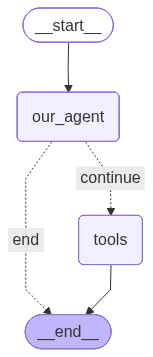

In [11]:
from IPython.display import Image,display

display(Image(app.get_graph().draw_mermaid_png()))